<a href="https://colab.research.google.com/github/kartheek018/-Best-Seller-Insights/blob/main/morgan_stanley_fx_forward_training_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Morgan Stanley FX Forward — LayoutLMv3 Training + Portable Inference

This notebook is intentionally scoped to **Morgan Stanley FX Forward PDFs only**. It converts the supported digital PDF layout into LayoutLMv3 training examples using PyMuPDF, creates rule-assisted BIO labels for this exact report structure, trains/validates/tests the model, saves the complete model + processor, and exposes a one-call PDF → JSON inference function.

It does **not** contain RAG, multi-counterparty routing, Options/Futures/CDS handling, or generic-layout logic. Unsupported documents are rejected instead of being silently processed.


## Section 1 — Install Dependencies

PyMuPDF extracts native PDF words and renders pages. The remaining libraries support the same LayoutLMv3 pipeline as your receipt notebook. Restart the kernel/session after first installation. No OCR service, LLM API, frontend, or separate package structure is needed.

In [1]:
%pip install -U "pymupdf>=1.24,<1.27" "transformers==4.57.1" "datasets>=3.6" "accelerate>=1.1,<2" "pillow>=10,<12" "numpy>=1.24,<3" pandas "matplotlib>=3.7,<4" scikit-learn


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 443.2 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 2.1 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of datasets to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 34.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.1/24.1 MB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 36.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 42.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 43.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 28.6

## Section 2 — Imports

Use PyMuPDF (`fitz`) for parsing and Pillow for page visualization. `Decimal` preserves financial amounts without floating-point rounding.

In [1]:
import json
import re
import sys
import hashlib
from pathlib import Path
from collections import defaultdict, Counter
from datetime import datetime
from decimal import Decimal, InvalidOperation

import numpy as np
import pandas as pd
import torch
import fitz
from PIL import Image, ImageDraw
from IPython.display import display
from datasets import Dataset, DatasetDict
from transformers import (
    AutoProcessor,
    AutoModelForTokenClassification,
    Trainer,
    TrainingArguments,
    default_data_collator,
    set_seed,
)
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support,
    classification_report as word_classification_report,
)
import matplotlib.pyplot as plt

print("PyMuPDF:", fitz.VersionBind)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


PyMuPDF: 1.26.7
PyTorch: 2.11.0+cu130
CUDA available: True
GPU: Tesla T4


## Section 3 — Colab Dataset and Model Configuration

Mount Google Drive, then use:

- Dataset: `/content/drive/MyDrive/personal/dataset` with `train`, `validation` and `test` subfolders.
- Model output: `/content/drive/MyDrive/personal/model-output`. The saved model survives runtime resets.

For the first quick run, use **1 epoch** and up to **100 training / 20 validation / 20 test PDFs**. Later, increase `EPOCHS` and set each value in `MAX_PDFS_PER_SPLIT` to `None` to use all PDFs. Select a GPU in Colab under **Runtime → Change runtime type**.

`USE_UNREVIEWED_RULE_LABELS=True` uses automatic annotations for this POC. Independently review validation/test labels before making accuracy claims.


In [2]:
# ---- Environment / persistent paths ----
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    PROJECT_DIR = Path("/content/drive/MyDrive/personal")
else:
    PROJECT_DIR = Path("/Users/kartheek/document-ml-project")

DATASET_DIR = PROJECT_DIR / "dataset"
MODEL_DIR = PROJECT_DIR / "model-output"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR = str(MODEL_DIR)

# ---- Supported document scope: DO NOT broaden this POC silently ----
SUPPORTED_LAYOUT = "morgan_stanley_fx_forward_v1"
SUPPORTED_ACTIVITY_TEXT = "Activity - FX Forwards"
SUPPORTED_REQUIRED_TEXT = [
    "Morgan Stanley",
    "Trade Ref No",
    "Order No",
    "CCY Pair",
    "Trade Date",
    "Settle Date",
    "Transaction Description",
    "Trade Price",
]


SPLITS = ["train", "validation", "test"]

# Fast POC defaults. Change values to None when you want the full dataset.
MAX_PDFS_PER_SPLIT = {"train": 100, "validation": 20, "test": 20}
MAX_PAGES_PER_PDF = None

ANNOTATION_PATH = DATASET_DIR / "morgan_stanley_fx_forward_annotations.json"

# PDF files do not contain gold entity labels. The current POC uses a layout rule
# to draft labels. Human review is still recommended, especially for validation/test.
USE_UNREVIEWED_RULE_LABELS = True

MODEL_NAME = "microsoft/layoutlmv3-base"
MAX_LENGTH = 512
STRIDE = 128
SEED = 42

RUN_TRAINING = True
RUN_MODEL_INFERENCE = False

EPOCHS = 1  # First quick run; increase later using validation results.
BATCH_SIZE = 2

META_FIELDS = [
    "ACCOUNT_NUMBER", "ACCOUNT_NAME", "REPORT_ID", "BASE_CCY",
    "ACTIVITY", "SUB_ACCOUNT", "CUSTODIAN"
]

ROW_FIELDS = [
    "TRADE_REF", "ORDER_NO", "CCY_PAIR", "TRADE_DATE", "SETTLE_DATE",
    "TRANSACTION_DESCRIPTION", "LEG1_AMOUNT", "LEG1_CCY",
    "LEG2_AMOUNT", "LEG2_CCY", "TRADE_PRICE"
]

FIELDS = META_FIELDS + ROW_FIELDS
LABELS = ["O"] + [
    label
    for field in FIELDS
    for label in (f"B-{field}", f"I-{field}")
]

label2id = {label: i for i, label in enumerate(LABELS)}
id2label = {i: label for label, i in label2id.items()}

set_seed(SEED)

print("Project:", PROJECT_DIR)
print("Dataset:", DATASET_DIR)
print("Model output:", MODEL_DIR)
print("Training epochs:", EPOCHS)
print("Field types:", len(FIELDS), "BIO labels:", len(LABELS))

assert DATASET_DIR.is_dir(), (
    f"Dataset folder not found: {DATASET_DIR}. "
    "In Colab upload/move dataset/train, dataset/validation and dataset/test under PROJECT_DIR."
)

PDFS_BY_SPLIT = {}

for split in SPLITS:
    folder = DATASET_DIR / split
    assert folder.is_dir(), f"Missing dataset split: {folder}"

    paths = sorted(
        path for path in folder.rglob("*")
        if path.is_file() and path.suffix.lower() == ".pdf"
    )

    limit = MAX_PDFS_PER_SPLIT[split]
    assert limit is None or (isinstance(limit, int) and limit > 0)

    PDFS_BY_SPLIT[split] = paths if limit is None else paths[:limit]
    assert PDFS_BY_SPLIT[split], f"No PDFs found in {folder}"

print("PDF files selected:", {
    split: len(paths) for split, paths in PDFS_BY_SPLIT.items()
})
print(
    "Label mode:",
    "rule-assisted (not independently reviewed gold)"
    if USE_UNREVIEWED_RULE_LABELS
    else "reviewed annotations only"
)


Mounted at /content/drive
Project: /content/drive/MyDrive/personal
Dataset: /content/drive/MyDrive/personal/dataset
Model output: /content/drive/MyDrive/personal/model-output
Training epochs: 1
Field types: 18 BIO labels: 37
PDF files selected: {'train': 100, 'validation': 20, 'test': 20}
Label mode: rule-assisted (not independently reviewed gold)


## Section 4 — Read Training, Validation and Testing PDFs

Extract native word rectangles and render the same page. Normalize PDF coordinates to 0–1000 using original page dimensions. No OCR is used for these digital reports.

Every page retains its source folder (`split`), document hash and page number. Exact PDF or extracted-page duplicates across splits raise an error; duplicates within a folder are not reassigned. Rotated/cropped/scanned PDFs need separate handling rather than silently producing wrong boxes.


Read train: 50/100 PDFs
Read train: 100/100 PDFs
Read validation: 20/20 PDFs
Read test: 20/20 PDFs
Extracted pages: {'train': 100, 'validation': 20, 'test': 20}
Distinct PDF content: {'train': 100, 'validation': 20, 'test': 20}


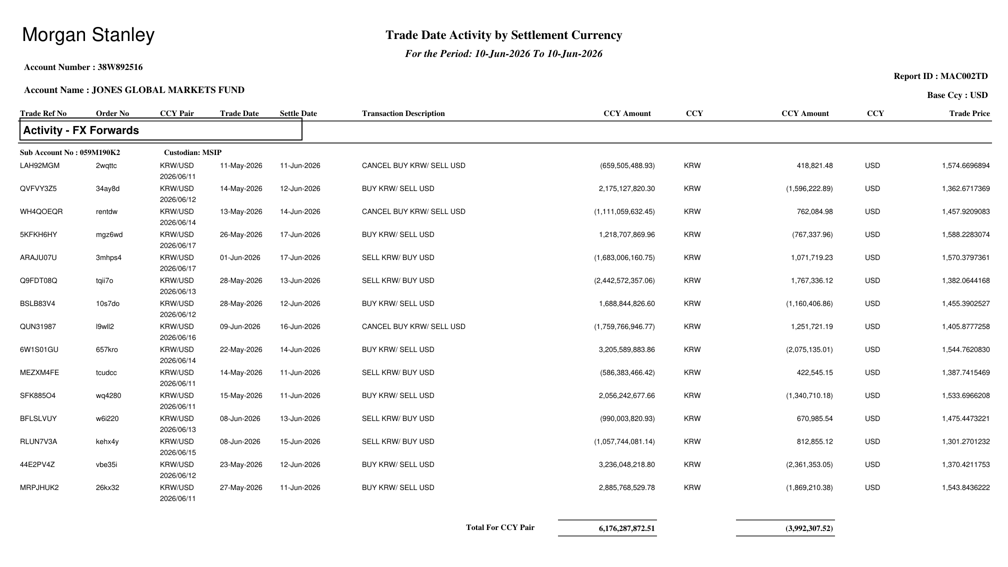

Sample: morgan_stanley_train_0001.pdf words: 299
[('Morgan', [22.0, 20.57499885559082, 86.4100112915039, 46.680999755859375]), ('Stanley', [91.69200897216797, 20.57499885559082, 155.0570068359375, 46.680999755859375]), ('Trade', [385.45001220703125, 25.950000762939453, 418.0874938964844, 43.26250076293945]), ('Date', [421.2124938964844, 25.950000762939453, 446.1999816894531, 43.26250076293945]), ('Activity', [449.3249816894531, 25.950000762939453, 491.67498779296875, 43.26250076293945]), ('by', [494.79998779296875, 25.950000762939453, 508.0, 43.26250076293945]), ('Settlement', [511.125, 25.950000762939453, 568.0498657226562, 43.26250076293945]), ('Currency', [571.1748657226562, 25.950000762939453, 622.5498657226562, 43.26250076293945])]


In [3]:

def assert_supported_pdf(path):
    """Reject anything outside the current Morgan Stanley FX Forward POC."""
    path = Path(path)
    with fitz.open(path) as doc:
        assert len(doc) > 0, f"Empty PDF: {path}"
        # The current report repeats/contains the relevant identifying text in native PDF text.
        text = "\n".join(page.get_text("text") for page in doc)
    normalized = re.sub(r"\s+", " ", text).strip()

    missing = [value for value in SUPPORTED_REQUIRED_TEXT if value.lower() not in normalized.lower()]
    assert not missing, (
        "Unsupported PDF for this notebook. "
        f"Missing Morgan Stanley FX Forward markers: {missing}. File: {path.name}"
    )
    assert SUPPORTED_ACTIVITY_TEXT.lower() in normalized.lower(), (
        f"Unsupported activity. Expected '{SUPPORTED_ACTIVITY_TEXT}'. File: {path.name}"
    )
    return True

def normalize_pdf_box(box, width, height):
    x0, y0, x1, y1 = box
    assert 0 <= x0 <= x1 <= width and 0 <= y0 <= y1 <= height, box
    return [int(1000*x0/width), int(1000*y0/height), int(1000*x1/width), int(1000*y1/height)]

def extract_pdf(path):
    path = Path(path)
    assert path.is_file(), f"PDF not found: {path.resolve()}"
    assert_supported_pdf(path)
    document_id = hashlib.sha256(path.read_bytes()).hexdigest()
    result = []
    with fitz.open(path) as doc:
        page_count = len(doc) if MAX_PAGES_PER_PDF is None else min(len(doc), MAX_PAGES_PER_PDF)
        for page_number in range(page_count):
            page = doc[page_number]
            assert page.rotation == 0, "Normalize PDF rotation before using this starter."
            assert page.cropbox == page.mediabox, "Cropped PDFs need coordinate reconciliation first."
            raw = page.get_text("words", sort=False)
            assert raw, f"No native text on page {page_number+1}; this page needs OCR."
            words = [item[4] for item in raw]
            boxes = [list(map(float, item[:4])) for item in raw]
            signature = hashlib.sha256(json.dumps([document_id, page_number, words, boxes]).encode()).hexdigest()
            result.append({"document_id": document_id, "page_id": f"{document_id[:16]}:p{page_number+1}",
                "pdf_path": str(path.resolve()), "page_number": page_number+1,
                "width": float(page.rect.width), "height": float(page.rect.height),
                "words": words, "pdf_boxes": boxes,
                "bboxes": [normalize_pdf_box(box, page.rect.width, page.rect.height) for box in boxes],
                "line_ids": [[int(item[5]), int(item[6])] for item in raw], "signature": signature})
    return result

def render_page(record):
    with fitz.open(record["pdf_path"]) as doc:
        pix = doc[record["page_number"]-1].get_pixmap(matrix=fitz.Matrix(2, 2), alpha=False)
        return Image.frombytes("RGB", [pix.width, pix.height], pix.samples)

pages, document_splits, page_content_splits = [], {}, {}
for split, paths in PDFS_BY_SPLIT.items():
    for file_index, path in enumerate(paths, start=1):
        extracted = extract_pdf(path)
        document_id = extracted[0]["document_id"]
        if document_id in document_splits:
            assert document_splits[document_id] == split, f"Same PDF content occurs in different splits: {path}"
            print("Skipping duplicate PDF within", split, ":", path.name)
            continue
        document_splits[document_id] = split
        for record in extracted:
            content_key = hashlib.sha256(json.dumps([record["words"], record["pdf_boxes"]]).encode()).hexdigest()
            previous_split = page_content_splits.get(content_key)
            assert previous_split is None or previous_split == split, f"Identical extracted page appears across splits: {path}"
            page_content_splits[content_key] = split
            record["split"] = split
            pages.append(record)
        if file_index % 50 == 0 or file_index == len(paths):
            print(f"Read {split}: {file_index}/{len(paths)} PDFs", flush=True)
print("Extracted pages:", dict(Counter(record["split"] for record in pages)))
print("Distinct PDF content:", dict(Counter(document_splits.values())))
display(render_page(pages[0]).resize((1008, 567)))
print("Sample:", Path(pages[0]["pdf_path"]).name, "words:", len(pages[0]["words"]))
print(list(zip(pages[0]["words"], pages[0]["pdf_boxes"]))[:8])

## Section 5 — Generate Rule-Assisted Training Labels

Detect the table headers, derive column boundaries and identify each transaction row. Metadata is labelled from key/value lines. Duplicate trade references remain distinct rows.

The pair's auxiliary date stays O; table totals, titles and column headings stay O. Unsupported layouts or incomplete fields are flagged. These are draft automatic labels, not human-reviewed ground truth. Section 10 checks eligibility before training/validation/testing.


In [4]:
def pdf_lines(record):
    groups = defaultdict(list)
    for index, line_id in enumerate(record["line_ids"]):
        groups[tuple(line_id)].append(index)
    return sorted(groups.values(), key=lambda ids: (record["pdf_boxes"][ids[0]][1], record["pdf_boxes"][ids[0]][0]))

def fields_to_bio(fields, row_ids):
    labels, previous = [], None
    for field, row_id in zip(fields, row_ids):
        key = (field, row_id) if field else None
        labels.append("O" if field is None else ("I-" if key == previous else "B-") + field)
        previous = key
    return labels

def suggest_annotations(record):
    result = dict(record)
    words, boxes = record["words"], record["pdf_boxes"]
    fields, row_ids = [None]*len(words), [None]*len(words)
    lines = pdf_lines(record)
    issues = []
    metadata_patterns = [("ACCOUNT_NUMBER", r"^Account Number\s*:\s*"),
        ("ACCOUNT_NAME", r"^Account Name\s*:\s*"), ("REPORT_ID", r"^Report ID\s*:\s*"),
        ("BASE_CCY", r"^Base Ccy\s*:\s*"), ("ACTIVITY", r"^Activity\s*-\s*"),
        ("SUB_ACCOUNT", r"^Sub Account No\s*:\s*"), ("CUSTODIAN", r"^Custodian:\s*")]
    for ids in lines:
        text = " ".join(words[i] for i in ids)
        for field, pattern in metadata_patterns:
            match = re.match(pattern, text, flags=re.I)
            if match:
                offset = 0
                for i in ids:
                    if offset >= match.end():
                        fields[i] = field
                    offset += len(words[i]) + 1
    header_names = ["Trade Ref No", "Order No", "CCY Pair", "Trade Date", "Settle Date",
                    "Transaction Description", "CCY Amount", "CCY", "CCY Amount", "CCY", "Trade Price"]
    header_start = next((ids for ids in lines if " ".join(words[i] for i in ids) == "Trade Ref No"), None)
    row_bands = []
    if header_start is None:
        issues.append("Unsupported header layout: label manually or add a new annotation rule.")
    else:
        header_y = boxes[header_start[0]][1]
        headers = sorted([ids for ids in lines if abs(boxes[ids[0]][1]-header_y) < 2], key=lambda ids: boxes[ids[0]][0])
        actual = [" ".join(words[i] for i in ids) for ids in headers]
        if actual != header_names:
            issues.append(f"Unexpected header cells: {actual}")
        else:
            centers = [(min(boxes[i][0] for i in ids)+max(boxes[i][2] for i in ids))/2 for ids in headers]
            boundaries = [0] + [(a+b)/2 for a,b in zip(centers, centers[1:])] + [record["width"]]
            anchors = sorted([(i, (box[1]+box[3])/2) for i, (word,box) in enumerate(zip(words,boxes))
                if box[1] > header_y+12 and (box[0]+box[2])/2 < boundaries[1]
                and re.fullmatch(r"[A-Z0-9][A-Z0-9._-]{5,19}", word)], key=lambda pair: pair[1])
            if not anchors:
                issues.append("No transaction row anchors detected.")
            for row_index, (anchor_id, anchor_y) in enumerate(anchors):
                top = (anchors[row_index-1][1]+anchor_y)/2 if row_index else boxes[anchor_id][1]-1
                bottom = (anchor_y+anchors[row_index+1][1])/2 if row_index+1<len(anchors) else boxes[anchor_id][3]+14
                row_id = f"{record['page_id']}:r{row_index+1:03}"
                row_bands.append({"row_id":row_id,"top":top,"bottom":bottom})
                for i, (word,box) in enumerate(zip(words,boxes)):
                    cx,cy = (box[0]+box[2])/2, (box[1]+box[3])/2
                    if not top <= cy < bottom:
                        continue
                    row_ids[i] = row_id
                    column = next((j for j in range(len(ROW_FIELDS)) if boundaries[j]<=cx<boundaries[j+1]), None)
                    if column is None:
                        continue
                    field = ROW_FIELDS[column]
                    # Ignore an auxiliary date printed under the CCY Pair.
                    if field == "CCY_PAIR" and not re.fullmatch(r"[A-Z]{3}/[A-Z]{3}", word):
                        continue
                    fields[i] = field
    result.update(labels=fields_to_bio(fields,row_ids), row_ids=row_ids,
                  row_bands=row_bands, reviewed=False, annotation_source="header_geometry_draft", issues=issues)
    return result

annotations = [suggest_annotations(record) for record in pages]
for split in SPLITS:
    group = [record for record in annotations if record["split"] == split]
    print(split, "pages:", len(group), "suggested transaction rows:", sum(len(record["row_bands"]) for record in group),
          "pages with rule issues:", sum(bool(record["issues"]) for record in group))
for index in range(min(85, len(annotations[0]["words"]))):
    if annotations[0]["labels"][index] != "O":
        print(index, annotations[0]["words"][index], annotations[0]["labels"][index])

train pages: 100 suggested transaction rows: 1500 pages with rule issues: 0
validation pages: 20 suggested transaction rows: 300 pages with rule issues: 0
test pages: 20 suggested transaction rows: 300 pages with rule issues: 0
11 MAC002TD B-REPORT_ID
15 USD B-BASE_CCY
39 FX B-ACTIVITY
40 Forwards I-ACTIVITY
45 059M190K2 B-SUB_ACCOUNT
47 MSIP B-CUSTODIAN
57 38W892516 B-ACCOUNT_NUMBER
61 JONES B-ACCOUNT_NAME
62 GLOBAL I-ACCOUNT_NAME
63 MARKETS I-ACCOUNT_NAME
64 FUND I-ACCOUNT_NAME
65 LAH92MGM B-TRADE_REF
66 2wqttc B-ORDER_NO
67 KRW/USD B-CCY_PAIR
69 11-May-2026 B-TRADE_DATE
70 11-Jun-2026 B-SETTLE_DATE
71 CANCEL B-TRANSACTION_DESCRIPTION
72 BUY I-TRANSACTION_DESCRIPTION
73 KRW/ I-TRANSACTION_DESCRIPTION
74 SELL I-TRANSACTION_DESCRIPTION
75 USD I-TRANSACTION_DESCRIPTION
76 (659,505,488.93) B-LEG1_AMOUNT
77 KRW B-LEG1_CCY
78 418,821.48 B-LEG2_AMOUNT
79 USD B-LEG2_CCY
80 1,574.6696894 B-TRADE_PRICE
81 QVFVY3Z5 B-TRADE_REF
82 34ay8d B-ORDER_NO
83 KRW/USD B-CCY_PAIR


## Section 6 — Review Tables and Source Boxes

`review_frame()` shows each suggested row field, its value and the word indices to edit. Draw all non-O boxes on the PDF image. Repeated IDs/amounts are not matched by value; page/row/word positions distinguish occurrences.

Review the full page, metadata and O words too. Draft labels must not silently become ground truth.

,row_id,field,value,word_indices
0,metadata,REPORT_ID,MAC002TD,[11]
1,metadata,BASE_CCY,USD,[15]
2,metadata,ACTIVITY,FX Forwards,"[39, 40]"
3,metadata,SUB_ACCOUNT,059M190K2,[45]
4,metadata,CUSTODIAN,MSIP,[47]
5,metadata,ACCOUNT_NUMBER,38W892516,[57]
6,metadata,ACCOUNT_NAME,JONES GLOBAL MARKETS FUND,"[61, 62, 63, 64]"
7,581ea2c7f001c4fd:p1:r001,TRADE_REF,LAH92MGM,[65]
8,581ea2c7f001c4fd:p1:r001,ORDER_NO,2wqttc,[66]
9,581ea2c7f001c4fd:p1:r001,CCY_PAIR,KRW/USD,[67]


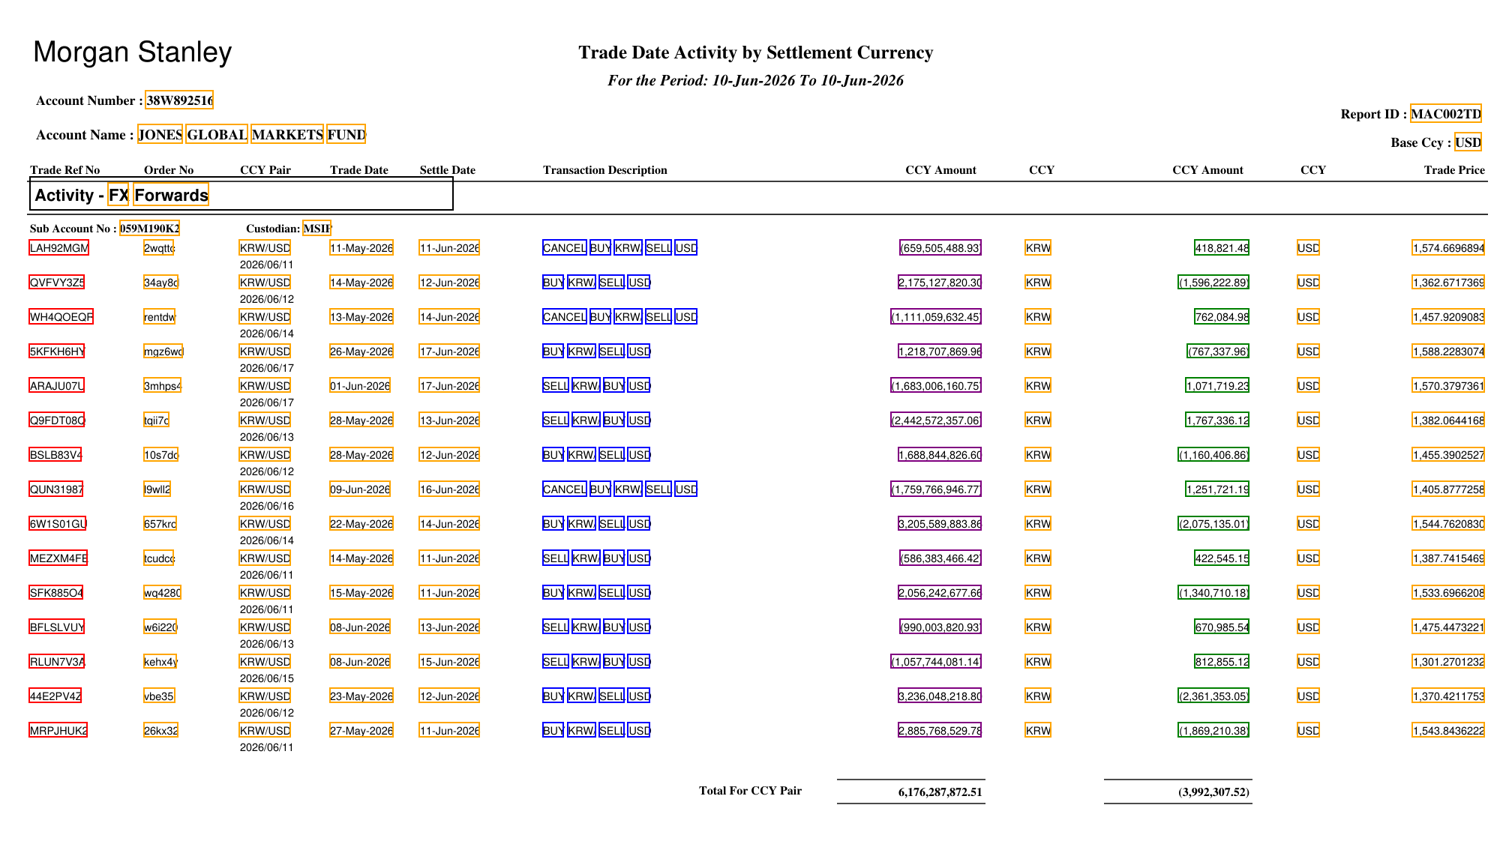

,word_index,word,label,row_id
0,0,Morgan,O,NaN
1,1,Stanley,O,NaN
2,2,Trade,O,NaN
3,3,Date,O,NaN
4,4,Activity,O,NaN
5,5,by,O,NaN
6,6,Settlement,O,NaN
7,7,Currency,O,NaN
8,8,Report,O,NaN
9,9,ID,O,NaN


In [5]:
def field_name(label):
    return None if label == "O" else label.split("-",1)[1]

def review_frame(record):
    groups = defaultdict(list)
    for i,(label,row_id) in enumerate(zip(record["labels"],record["row_ids"])):
        field = field_name(label)
        if field:
            groups[(row_id,field)].append(i)
    return pd.DataFrame([{"row_id": row_id or "metadata", "field": field,
        "value": " ".join(record["words"][i] for i in ids), "word_indices": ids}
        for (row_id,field),ids in groups.items()])

def draw_labels(record, labels=None):
    image = render_page(record)
    draw = ImageDraw.Draw(image)
    labels = record["labels"] if labels is None else labels
    colors = {"TRADE_REF":"red", "TRANSACTION_DESCRIPTION":"blue", "LEG1_AMOUNT":"purple", "LEG2_AMOUNT":"green"}
    for box,label in zip(record["bboxes"],labels):
        field = field_name(label)
        if not field:
            continue
        x0,y0,x1,y1 = box
        rect = [x0*image.width/1000,y0*image.height/1000,x1*image.width/1000,y1*image.height/1000]
        draw.rectangle(rect, outline=colors.get(field,"orange"), width=2)
    return image

pd.set_option("display.max_rows", 200)
display(review_frame(annotations[0]))
display(draw_labels(annotations[0]).resize((1512,850)))
# To inspect O words or exact label positions:
display(pd.DataFrame({"word_index":range(len(annotations[0]["words"])),
    "word":annotations[0]["words"], "label":annotations[0]["labels"], "row_id":annotations[0]["row_ids"]}).head(85))

## Section 7 — Build a Rule-Based Transaction Preview

The current PDF has 15 rows. Keep every row—including CANCEL and repeated trade references. Extract LEG1/LEG2 first, then derive BUY/SELL from description currency/action pairs, not signs. Cancellation reverses signs; it does not change the wording's buy/sell directions.

Keep signed raw amounts, positive buy/sell magnitudes and a cancellation flag. Do not net/delete trades or apply business cancellation semantics. `2026/06/08` under the pair remains ignored because its business meaning has not been established. Missing/conflicting fields are reported, never fabricated.

This is an immediately useful **rule baseline and annotation preview**, not trained-model output.

In [6]:
def parse_decimal(text):
    value = text.strip().replace(",", "")
    if value.startswith("(") and value.endswith(")"):
        value = "-" + value[1:-1]
    if not re.fullmatch(r"-?\d+(?:\.\d+)?", value):
        raise ValueError(f"Unrecognized numeric value: {text}")
    return Decimal(value)

def iso_date(text):
    for fmt in ["%d-%b-%Y", "%Y/%m/%d", "%Y-%m-%d"]:
        try:
            return datetime.strptime(text,fmt).date().isoformat()
        except ValueError:
            pass
    return text

def merge_entities(record, labels, confidences=None):
    entities,current = [],None
    confidences = [None]*len(labels) if confidences is None else confidences
    for i,(label,row_id,score) in enumerate(zip(labels,record["row_ids"],confidences)):
        field = field_name(label)
        if field is None:
            current = None
            continue
        if label.startswith("B-") or current is None or (current["field"],current["row_id"]) != (field,row_id):
            current = {"field":field,"row_id":row_id,"word_indices":[],"scores":[]}
            entities.append(current)
        current["word_indices"].append(i)
        if score is not None:
            current["scores"].append(float(score))
    result = []
    for entity in entities:
        ids = entity["word_indices"]; boxes = [record["bboxes"][i] for i in ids]
        result.append({"field":entity["field"],"row_id":entity["row_id"],
            "value":" ".join(record["words"][i] for i in ids), "page":record["page_number"],
            "bbox":[min(b[0] for b in boxes),min(b[1] for b in boxes),max(b[2] for b in boxes),max(b[3] for b in boxes)],
            "word_indices":ids,"confidence":float(np.mean(entity["scores"])) if entity["scores"] else None})
    return result

def transaction_json(record, labels=None, confidences=None, source="rule_draft"):
    labels = record["labels"] if labels is None else labels
    entities = merge_entities(record, labels, confidences)
    metadata,transactions = {},[]
    for field in META_FIELDS:
        candidates = [e for e in entities if e["field"]==field and e["row_id"] is None]
        metadata[field.lower()] = candidates[0]["value"] if len(candidates)==1 else None
    for band in record["row_bands"]:
        row_id = band["row_id"]
        row = {"row_id":row_id,"page":record["page_number"],"issues":[],"evidence":{}}
        for field in ROW_FIELDS:
            candidates = [e for e in entities if e["row_id"]==row_id and e["field"]==field]
            row[field.lower()] = candidates[0]["value"] if len(candidates)==1 else None
            if len(candidates)==1:
                row["evidence"][field.lower()] = candidates[0]
            else:
                row["issues"].append(f"{field}: {len(candidates)} candidates")
        for field in ["trade_date","settle_date"]:
            if row[field]:
                raw_value=row[field]; row[field]=iso_date(raw_value)
                if not re.fullmatch(r"\d{4}-\d{2}-\d{2}", row[field]):
                    row["issues"].append(f"Unrecognized {field}: {raw_value}")
        description = row["transaction_description"] or ""
        row["is_cancellation"] = bool(re.search(r"\bCANCEL\b",description))
        actions = re.findall(r"\b(BUY|SELL)\s+([A-Z]{3})",description.upper())
        row.update(buy_currency=None,buy_amount=None,sell_currency=None,sell_amount=None)
        if len(actions)!=2 or {action for action,ccy in actions}!={"BUY","SELL"} or len({ccy for action,ccy in actions})!=2:
            row["issues"].append("Description does not identify exactly one BUY and SELL currency")
        else:
            for action,currency in actions:
                legs=[leg for leg in [1,2] if row[f"leg{leg}_ccy"]==currency]
                if len(legs)!=1 or not row[f"leg{legs[0]}_amount"]:
                    row["issues"].append(f"Cannot map {action} {currency} to one leg")
                    continue
                try:
                    amount=parse_decimal(row[f"leg{legs[0]}_amount"])
                    row[f"{action.lower()}_currency"]=currency
                    row[f"{action.lower()}_amount"]=format(abs(amount),"f")
                except (ValueError,InvalidOperation) as error:
                    row["issues"].append(str(error))
        pair=row["ccy_pair"]
        if pair and set(pair.split("/")) != {row["leg1_ccy"],row["leg2_ccy"]}:
            row["issues"].append("CCY pair and leg currencies disagree")
        transactions.append(row)
    return {"source":source,"annotation_reviewed":record["reviewed"],"document_id":record["document_id"],
            "page":record["page_number"],"metadata":metadata,"transactions":transactions}

rule_previews = [transaction_json(record) for record in annotations]
for split in SPLITS:
    group = [preview for record, preview in zip(annotations, rule_previews) if record["split"] == split]
    rows = [row for preview in group for row in preview["transactions"]]
    print(split, "rule-preview transactions:", len(rows), "rows with issues:", sum(bool(row["issues"]) for row in rows))
display(pd.DataFrame([{key:value for key,value in row.items() if key!="evidence"}
                      for row in rule_previews[0]["transactions"]]))
print(json.dumps(rule_previews[0]["transactions"][0], indent=2))

train rule-preview transactions: 1500 rows with issues: 0
validation rule-preview transactions: 300 rows with issues: 0
test rule-preview transactions: 300 rows with issues: 0


,row_id,page,issues,trade_ref,order_no,ccy_pair,trade_date,settle_date,transaction_description,leg1_amount,leg1_ccy,leg2_amount,leg2_ccy,trade_price,is_cancellation,buy_currency,buy_amount,sell_currency,sell_amount
0,581ea2c7f001c4fd:p1:r001,1,[],LAH92MGM,2wqttc,KRW/USD,2026-05-11,2026-06-11,CANCEL BUY KRW/ SELL USD,"(659,505,488.93)",KRW,"418,821.48",USD,"1,574.6696894",True,KRW,659505488.93,USD,418821.48
1,581ea2c7f001c4fd:p1:r002,1,[],QVFVY3Z5,34ay8d,KRW/USD,2026-05-14,2026-06-12,BUY KRW/ SELL USD,"2,175,127,820.30",KRW,"(1,596,222.89)",USD,"1,362.6717369",False,KRW,2175127820.30,USD,1596222.89
2,581ea2c7f001c4fd:p1:r003,1,[],WH4QOEQR,rentdw,KRW/USD,2026-05-13,2026-06-14,CANCEL BUY KRW/ SELL USD,"(1,111,059,632.45)",KRW,"762,084.98",USD,"1,457.9209083",True,KRW,1111059632.45,USD,762084.98
3,581ea2c7f001c4fd:p1:r004,1,[],5KFKH6HY,mgz6wd,KRW/USD,2026-05-26,2026-06-17,BUY KRW/ SELL USD,"1,218,707,869.96",KRW,"(767,337.96)",USD,"1,588.2283074",False,KRW,1218707869.96,USD,767337.96
4,581ea2c7f001c4fd:p1:r005,1,[],ARAJU07U,3mhps4,KRW/USD,2026-06-01,2026-06-17,SELL KRW/ BUY USD,"(1,683,006,160.75)",KRW,"1,071,719.23",USD,"1,570.3797361",False,USD,1071719.23,KRW,1683006160.75
5,581ea2c7f001c4fd:p1:r006,1,[],Q9FDT08Q,tqii7o,KRW/USD,2026-05-28,2026-06-13,SELL KRW/ BUY USD,"(2,442,572,357.06)",KRW,"1,767,336.12",USD,"1,382.0644168",False,USD,1767336.12,KRW,2442572357.06
6,581ea2c7f001c4fd:p1:r007,1,[],BSLB83V4,10s7do,KRW/USD,2026-05-28,2026-06-12,BUY KRW/ SELL USD,"1,688,844,826.60",KRW,"(1,160,406.86)",USD,"1,455.3902527",False,KRW,1688844826.60,USD,1160406.86
7,581ea2c7f001c4fd:p1:r008,1,[],QUN31987,l9wll2,KRW/USD,2026-06-09,2026-06-16,CANCEL BUY KRW/ SELL USD,"(1,759,766,946.77)",KRW,"1,251,721.19",USD,"1,405.8777258",True,KRW,1759766946.77,USD,1251721.19
8,581ea2c7f001c4fd:p1:r009,1,[],6W1S01GU,657kro,KRW/USD,2026-05-22,2026-06-14,BUY KRW/ SELL USD,"3,205,589,883.86",KRW,"(2,075,135.01)",USD,"1,544.7620830",False,KRW,3205589883.86,USD,2075135.01
9,581ea2c7f001c4fd:p1:r010,1,[],MEZXM4FE,tcudcc,KRW/USD,2026-05-14,2026-06-11,SELL KRW/ BUY USD,"(586,383,466.42)",KRW,"422,545.15",USD,"1,387.7415469",False,USD,422545.15,KRW,586383466.42


{
  "row_id": "581ea2c7f001c4fd:p1:r001",
  "page": 1,
  "issues": [],
  "evidence": {
    "trade_ref": {
      "field": "TRADE_REF",
      "row_id": "581ea2c7f001c4fd:p1:r001",
      "value": "LAH92MGM",
      "page": 1,
      "bbox": [
        19,
        282,
        59,
        300
      ],
      "word_indices": [
        65
      ],
      "confidence": null
    },
    "order_no": {
      "field": "ORDER_NO",
      "row_id": "581ea2c7f001c4fd:p1:r001",
      "value": "2wqttc",
      "page": 1,
      "bbox": [
        95,
        282,
        115,
        300
      ],
      "word_indices": [
        66
      ],
      "confidence": null
    },
    "ccy_pair": {
      "field": "CCY_PAIR",
      "row_id": "581ea2c7f001c4fd:p1:r001",
      "value": "KRW/USD",
      "page": 1,
      "bbox": [
        158,
        282,
        192,
        300
      ],
      "word_indices": [
        67
      ],
      "confidence": null
    },
    "trade_date": {
      "field": "TRADE_DATE",
      "row_id

## Section 8 — Annotation Review and Corrections

Load previously saved labels only when the PDF/extraction signature matches. Source folder assignments always come from the current folders, not old JSON entries.

Use word indices from Section 6 in LABEL_EDITS, or edit the annotation JSON. Set REVIEWED_PAGE_IDS only after inspecting the complete page and its O words. Corrections reset review status. Structural validation checks fields/rows, but does not establish semantic correctness.

Automatic labels can still be used in this POC with USE_UNREVIEWED_RULE_LABELS=True; they remain explicitly marked unreviewed. For an independent gold evaluation, review the validation/test annotations and set this flag False.


In [7]:
def validate_annotations(record):
    count=len(record["words"])
    assert count==len(record["bboxes"])==len(record["labels"])==len(record["row_ids"])
    previous=None
    for label,row_id in zip(record["labels"],record["row_ids"]):
        assert label in label2id, label
        field=field_name(label)
        key=(field,row_id) if field else None
        if label.startswith("I-"):
            assert key==previous, f"Invalid BIO continuation: {label}, {row_id}"
        if field in ROW_FIELDS:
            assert row_id is not None, f"Transaction field without a row: {label}"
        if field in META_FIELDS:
            assert row_id is None, f"Metadata field unexpectedly in transaction: {label}"
        previous=key
    known_rows={band["row_id"] for band in record["row_bands"]}
    assert all(row_id is None or row_id in known_rows for row_id in record["row_ids"])
    assert record["row_bands"], "No rows: annotate row geometry before training."
    preview=transaction_json(record)
    assert not record["issues"], f"Unresolved annotation rule issues: {record['issues']}"
    for field in META_FIELDS:
        assert preview["metadata"][field.lower()], f"Missing/ambiguous metadata field: {field}"
    for row in preview["transactions"]:
        assert not row["issues"], f"Resolve row issues before reviewing: {row['row_id']} {row['issues']}"

if ANNOTATION_PATH.exists():
    saved=json.loads(ANNOTATION_PATH.read_text())
    assert saved["labels"]==LABELS, "Annotation label vocabulary differs from configuration."
    saved_by_id={record["page_id"]:record for record in saved["pages"]}
    for index,current in enumerate(annotations):
        old=saved_by_id.get(current["page_id"])
        if old:
            assert old["signature"]==current["signature"], "PDF text/coordinates changed; regenerate annotations."
            # Keep the current path when moving a PDF from laptop to Colab/Drive.
            updated=dict(old);updated["pdf_path"]=current["pdf_path"];updated["split"]=current["split"]
            annotations[index]=updated

LABEL_EDITS = {}  # Example: {"<page_id>": {73: "B-TRANSACTION_DESCRIPTION", 74: "I-TRANSACTION_DESCRIPTION"}}
REVIEWED_PAGE_IDS = set()  # Example after actual review: {annotations[0]["page_id"]}
for record in annotations:
    edits=LABEL_EDITS.get(record["page_id"],{})
    if edits:
        record["reviewed"]=False
        for word_index,label in edits.items():
            assert isinstance(word_index,int) and 0<=word_index<len(record["words"])
            assert label in label2id
            record["labels"][word_index]=label
    if record["page_id"] in REVIEWED_PAGE_IDS:
        validate_annotations(record)
        record["reviewed"]=True
        record["annotation_source"]="human_reviewed_rule_draft"
print("Human-reviewed pages by split:", {split: sum(record["reviewed"] for record in annotations if record["split"]==split) for split in SPLITS})
print("First page ID for review:", annotations[0]["page_id"])
print("Rule labels remain unreviewed; Section 10 states whether they are eligible for this POC.")

Human-reviewed pages by split: {'train': 0, 'validation': 0, 'test': 0}
First page ID for review: 581ea2c7f001c4fd:p1
Rule labels remain unreviewed; Section 10 states whether they are eligible for this POC.


## Section 9 — Save the Training Label Dataset

Save `morgan_stanley_fx_forward_annotations.json` inside the dataset folder, including words, boxes, labels, source split and review status. PDFs are still required for rendering.


In [8]:
annotation_data={"schema_version":2,"labels":LABELS,"pages":annotations}
ANNOTATION_PATH.write_text(json.dumps(annotation_data,indent=2),encoding="utf-8")
print("Saved:",ANNOTATION_PATH.resolve())
print("Human-reviewed pages:",sum(record["reviewed"] for record in annotations),"/",len(annotations))

Saved: /content/drive/MyDrive/personal/dataset/morgan_stanley_fx_forward_annotations.json
Human-reviewed pages: 0 / 140


## Section 10 — Training Dataset / Validation Dataset / Test Dataset

Use the supplied folders directly: `train` → learning, `validation` → epoch checks/tuning, and `test` → final evaluation. No random resplit is performed, and all pages from one PDF stay in the same split.

The Colab POC configuration currently selects up to **100 train / 20 validation / 20 test PDFs** to keep runtime manageable. Change `MAX_PDFS_PER_SPLIT` to `None` later when you want to use all available PDFs.

Validate labels, metadata and transaction rows before training. Human-reviewed validation/test labels are strongly preferred for meaningful accuracy numbers.


In [9]:
# Preserve your folder assignments. No random train/test resplitting.
split_records = {split: [] for split in SPLITS}
excluded = []
for record in annotations:
    try:
        validate_annotations(record)
    except (AssertionError, ValueError) as error:
        excluded.append({"split": record["split"], "pdf": Path(record["pdf_path"]).name,
                         "page": record["page_number"], "reason": str(error)})
        continue
    if not record["reviewed"] and not USE_UNREVIEWED_RULE_LABELS:
        excluded.append({"split": record["split"], "pdf": Path(record["pdf_path"]).name,
                         "page": record["page_number"], "reason": "Not human-reviewed"})
        continue
    eligible = dict(record)
    eligible["label_source"] = "human_reviewed" if record["reviewed"] else "rule_assisted_unreviewed"
    split_records[record["split"]].append(eligible)

split_documents = {split: {record["document_id"] for record in records} for split, records in split_records.items()}
assert not (split_documents["train"] & split_documents["validation"] or
            split_documents["train"] & split_documents["test"] or
            split_documents["validation"] & split_documents["test"]), "PDF leakage between folder splits"
split_summary = pd.DataFrame([{"split": split, "input_pdfs": len(PDFS_BY_SPLIT[split]),
    "eligible_pdfs": len(split_documents[split]), "eligible_pages": len(records),
    "human_reviewed_pages": sum(record["reviewed"] for record in records),
    "rule_label_pages": sum(not record["reviewed"] for record in records)}
    for split, records in split_records.items()])
display(split_summary)
print("Excluded pages:", len(excluded))
if excluded:
    display(pd.DataFrame(excluded))
if RUN_TRAINING:
    assert all(split_records[split] for split in SPLITS), "Each folder needs eligible annotated pages. Review exclusions."
print("Metrics label source:", "rule-assisted unless human-reviewed; not an independent gold test" if USE_UNREVIEWED_RULE_LABELS else "human-reviewed only")

,split,input_pdfs,eligible_pdfs,eligible_pages,human_reviewed_pages,rule_label_pages
0,train,100,100,100,0,100
1,validation,20,20,20,0,20
2,test,20,20,20,0,20


Excluded pages: 0
Metrics label source: rule-assisted unless human-reviewed; not an independent gold test


## Section 11 — Inspect One Model Input

Processor inputs are page image + native words + normalized boxes + word labels. apply_ocr=False uses extracted PDF text. Only the first subword is supervised; other subwords/padding get -100.

Inspect shapes and full word coverage before bulk preparation. Overlapping 512-token windows retain transactions near the bottom. Sample labels may be automatic drafts; do not call them gold labels.


In [10]:
processor=AutoProcessor.from_pretrained(MODEL_NAME,apply_ocr=False)
processor.tokenizer.only_label_first_subword=True
one=annotations[0]
one_encoding=processor(render_page(one),one["words"],boxes=one["bboxes"],
    word_labels=[label2id[label] for label in one["labels"]],truncation=True,padding="max_length",
    max_length=MAX_LENGTH,return_overflowing_tokens=True,stride=STRIDE,return_tensors="pt")
if isinstance(one_encoding["pixel_values"],list):
    one_encoding["pixel_values"]=torch.stack(one_encoding["pixel_values"])
print({key:tuple(value.shape) for key,value in one_encoding.items()})
covered={word_id for window in range(one_encoding["input_ids"].shape[0])
         for word_id in one_encoding.word_ids(window) if word_id is not None}
assert len(covered)==len(one["words"])
print("Covered words:",len(covered),"/",len(one["words"]))

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/275 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/856 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

{'input_ids': (3, 512), 'attention_mask': (3, 512), 'overflow_to_sample_mapping': (3,), 'bbox': (3, 512, 4), 'labels': (3, 512), 'pixel_values': (3, 3, 224, 224)}
Covered words: 299 / 299


## Section 12 — Prepare Training, Validation and Testing Tensors

Preprocess one page at a time within its existing folder split. Each long page produces overlapping windows. Keep source provenance for annotation, but remove it from model tensors.

Print page/window counts per split. Training uses only encoded_splits['train']; validation and testing never update model weights. Overlap repeats some word positions in window metrics.


In [11]:
def prepare_page_batch(batch):
    record={key:value[0] for key,value in batch.items()}
    encoded=processor(render_page(record),record["words"],boxes=record["bboxes"],
        word_labels=[label2id[label] for label in record["labels"]],
        truncation=True,padding="max_length",max_length=MAX_LENGTH,
        return_overflowing_tokens=True,stride=STRIDE)
    return {key:value for key,value in encoded.items() if key!="overflow_to_sample_mapping"}

encoded_splits=DatasetDict()
if RUN_TRAINING:
    for split,records in split_records.items():
        source=Dataset.from_list(records)
        encoded_splits[split]=source.map(prepare_page_batch,batched=True,batch_size=1,
            remove_columns=source.column_names,desc=f"Preparing {split}").with_format("torch")
        print(split,"pages:",len(records),"windows:",len(encoded_splits[split]))
else:
    print("Full training preprocessing skipped (RUN_TRAINING=False).")

Preparing train:   0%|          | 0/100 [00:00<?, ? examples/s]

train pages: 100 windows: 300


Preparing validation:   0%|          | 0/20 [00:00<?, ? examples/s]

validation pages: 20 windows: 60


Preparing test:   0%|          | 0/20 [00:00<?, ? examples/s]

test pages: 20 windows: 60


## Section 13 — Accuracy, Precision, Recall, F1 and Per-Field Metrics

Targets marked `-100` are ignored. `accuracy` is exact BIO-label accuracy over supervised positions. `precision`, `recall`, and `f1` are strict entity-span metrics implemented directly in this notebook, so `seqeval` is not required.

The notebook also reports B/I-combined field accuracy and macro/weighted field precision/recall/F1, plus per-field entity F1. O-dominated accuracy can look high even while important fields are missed.

Metrics are only as trustworthy as the annotations used for validation/test. If those labels are automatically generated by the same layout rules used for training data preparation, treat the numbers as POC diagnostics rather than independent accuracy claims. Overlapping tokenizer windows can also count some positions more than once.


In [12]:
def _bio_entities(sequence):
    """Return strict BIO entities as (field, start, end_exclusive)."""
    entities = []
    current_field = None
    start = None

    def close(end):
        nonlocal current_field, start
        if current_field is not None:
            entities.append((current_field, start, end))
        current_field = None
        start = None

    for index, label in enumerate(sequence):
        if label == "O":
            close(index)
            continue

        prefix, field = label.split("-", 1)

        if prefix == "B":
            close(index)
            current_field = field
            start = index
        elif prefix == "I":
            if current_field != field:
                # Treat an invalid I-X as a new entity rather than crashing metrics.
                close(index)
                current_field = field
                start = index
        else:
            close(index)

    close(len(sequence))
    return entities


def _safe_prf(tp, fp, fn):
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall)
        else 0.0
    )
    return precision, recall, f1


def compute_metrics(evaluation):
    logits, targets = evaluation
    predicted = np.argmax(logits, axis=-1)

    keep = targets != -100
    true_ids = targets[keep]
    predicted_ids = predicted[keep]
    assert len(true_ids), "No supervised labels for evaluation"

    # Token-level fields (BIO prefix collapsed).
    true_fields = [field_name(id2label[int(value)]) or "O" for value in true_ids]
    predicted_fields = [
        field_name(id2label[int(value)]) or "O"
        for value in predicted_ids
    ]

    result = {
        "accuracy": float(accuracy_score(true_ids, predicted_ids)),
        "field_accuracy": float(accuracy_score(true_fields, predicted_fields)),
    }

    for average in ["macro", "weighted"]:
        precision, recall, f1, _ = precision_recall_fscore_support(
            true_fields,
            predicted_fields,
            labels=["O"] + FIELDS,
            average=average,
            zero_division=0,
        )
        result.update({
            f"field_{average}_precision": float(precision),
            f"field_{average}_recall": float(recall),
            f"field_{average}_f1": float(f1),
        })

    # Strict entity-level BIO metrics, implemented locally so seqeval is not required.
    total_tp = total_fp = total_fn = 0
    field_counts = {
        field: {"tp": 0, "fp": 0, "fn": 0}
        for field in FIELDS
    }

    for pred_row, target_row in zip(predicted, targets):
        truth = [
            id2label[int(t)]
            for t in target_row
            if t != -100
        ]
        guess = [
            id2label[int(p)]
            for p, t in zip(pred_row, target_row)
            if t != -100
        ]

        true_entities = set(_bio_entities(truth))
        pred_entities = set(_bio_entities(guess))

        matched = true_entities & pred_entities
        total_tp += len(matched)
        total_fp += len(pred_entities - true_entities)
        total_fn += len(true_entities - pred_entities)

        for field in FIELDS:
            tset = {e for e in true_entities if e[0] == field}
            pset = {e for e in pred_entities if e[0] == field}
            field_counts[field]["tp"] += len(tset & pset)
            field_counts[field]["fp"] += len(pset - tset)
            field_counts[field]["fn"] += len(tset - pset)

    precision, recall, f1 = _safe_prf(total_tp, total_fp, total_fn)
    result.update({
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
    })

    for field, counts in field_counts.items():
        _, _, field_f1 = _safe_prf(
            counts["tp"], counts["fp"], counts["fn"]
        )
        result[f"{field.lower()}_f1"] = float(field_f1)

    return result


def metric_summary(metrics, prefix):
    names = [
        "accuracy", "precision", "recall", "f1",
        "field_accuracy", "field_macro_precision",
        "field_macro_recall", "field_macro_f1",
        "field_weighted_f1",
    ]
    return pd.DataFrame([
        {"metric": name, "value": metrics[f"{prefix}_{name}"]}
        for name in names
        if f"{prefix}_{name}" in metrics
    ])


def confusion_table(logits, targets, collapse_bio=True):
    predicted = np.argmax(logits, axis=-1)
    assert predicted.shape == targets.shape

    keep = targets != -100
    truth = [id2label[int(value)] for value in targets[keep]]
    guesses = [id2label[int(value)] for value in predicted[keep]]

    if collapse_bio:
        truth = [field_name(label) or "O" for label in truth]
        guesses = [field_name(label) or "O" for label in guesses]

    classes = ["O"] + FIELDS if collapse_bio else LABELS
    matrix = confusion_matrix(truth, guesses, labels=classes)

    return pd.DataFrame(
        matrix,
        index=pd.Index(classes, name="Actual"),
        columns=pd.Index(classes, name="Predicted"),
    )


def plot_confusion(table):
    figure, axis = plt.subplots(figsize=(13, 10))
    heatmap = axis.imshow(np.log1p(table.to_numpy()), cmap="Blues")

    axis.set_xticks(
        range(len(table.columns)),
        labels=table.columns,
        rotation=90,
    )
    axis.set_yticks(
        range(len(table.index)),
        labels=table.index,
    )
    axis.set_xlabel("Predicted field")
    axis.set_ylabel("Actual field")
    axis.set_title("Test word-label confusion matrix (BIO prefixes combined)")

    for row, column in zip(*np.nonzero(table.to_numpy())):
        axis.text(
            column,
            row,
            str(table.iloc[row, column]),
            ha="center",
            va="center",
            fontsize=7,
        )

    figure.colorbar(heatmap, ax=axis, label="log(1 + count)")
    figure.tight_layout()
    plt.show()
    return figure


## Section 14 — Model Training on the Training Dataset

`trainer.train()` learns from **dataset/train only**, using LayoutLMv3 base with a new financial classifier.

The first run uses **1 epoch**: each selected training window is visited once. Validation runs at the end without updating weights. Start with a Colab GPU; mixed precision is enabled on CUDA.

Increase `EPOCHS` in Section 3 later based on validation results. Testing and confusion matrices follow in Sections 16–17; Section 18 saves the model to Drive.


In [13]:
trainer = None

if RUN_TRAINING:
    assert "train" in encoded_splits and len(encoded_splits["train"]) > 0

    model = AutoModelForTokenClassification.from_pretrained(
        MODEL_NAME,
        num_labels=len(LABELS),
        label2id=label2id,
        id2label=id2label,
    )

    has_validation = (
        "validation" in encoded_splits
        and len(encoded_splits["validation"]) > 0
    )

    arguments = TrainingArguments(
        output_dir=OUTPUT_DIR,
        learning_rate=5e-5,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE,
        num_train_epochs=EPOCHS,
        weight_decay=0.01,
        eval_strategy="epoch" if has_validation else "no",
        save_strategy="no",
        load_best_model_at_end=False,
        logging_steps=5,
        report_to="none",
        seed=SEED,
        dataloader_num_workers=0,
        dataloader_pin_memory=torch.cuda.is_available(),
        fp16=torch.cuda.is_available(),
    )

    trainer = Trainer(
        model=model,
        args=arguments,
        train_dataset=encoded_splits["train"],
        eval_dataset=encoded_splits.get("validation"),
        data_collator=default_data_collator,
        compute_metrics=compute_metrics,
    )

    trainer.train()
    display(trainer.state.log_history)

    print(
        "Training complete. Section 15: validation; "
        "Section 16: testing; Section 17: confusion matrices."
    )
else:
    print(
        "Training disabled. Set RUN_TRAINING=True "
        "in Section 3 to train on eligible labels."
    )


model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

Some weights of LayoutLMv3ForTokenClassification were not initialized from the model checkpoint at microsoft/layoutlmv3-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.13/dist-packages/transformers/modeling_utils.py:1621: FutureWarning: The `device` argument is deprecated and will be removed in v5 of Transformers.
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy,Field Accuracy,Field Macro Precision,Field Macro Recall,Field Macro F1,Field Weighted Precision,Field Weighted Recall,Field Weighted F1,Precision,Recall,F1,Account Number F1,Account Name F1,Report Id F1,Base Ccy F1,Activity F1,Sub Account F1,Custodian F1,Trade Ref F1,Order No F1,Ccy Pair F1,Trade Date F1,Settle Date F1,Transaction Description F1,Leg1 Amount F1,Leg1 Ccy F1,Leg2 Amount F1,Leg2 Ccy F1,Trade Price F1
1,0.045700,0.032871,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


[{'loss': 3.0665,
  'grad_norm': 4.172183990478516,
  'learning_rate': 4.866666666666667e-05,
  'epoch': 0.03333333333333333,
  'step': 5},
 {'loss': 2.1411,
  'grad_norm': 4.656330108642578,
  'learning_rate': 4.7e-05,
  'epoch': 0.06666666666666667,
  'step': 10},
 {'loss': 1.4976,
  'grad_norm': 3.899407386779785,
  'learning_rate': 4.5333333333333335e-05,
  'epoch': 0.1,
  'step': 15},
 {'loss': 0.9984,
  'grad_norm': 2.514031171798706,
  'learning_rate': 4.3666666666666666e-05,
  'epoch': 0.13333333333333333,
  'step': 20},
 {'loss': 0.6952,
  'grad_norm': 1.903311014175415,
  'learning_rate': 4.2e-05,
  'epoch': 0.16666666666666666,
  'step': 25},
 {'loss': 0.4829,
  'grad_norm': 1.3576687574386597,
  'learning_rate': 4.0333333333333336e-05,
  'epoch': 0.2,
  'step': 30},
 {'loss': 0.3127,
  'grad_norm': 0.9856471419334412,
  'learning_rate': 3.866666666666667e-05,
  'epoch': 0.23333333333333334,
  'step': 35},
 {'loss': 0.2237,
  'grad_norm': 0.8230977058410645,
  'learning_rate

Training complete. Section 15: validation; Section 16: testing; Section 17: confusion matrices.


## Section 15 — Model Validation on the Validation Dataset

Trainer already checks validation after each epoch. This cell displays the final model's validation metrics explicitly using **dataset/validation**. It never updates model weights. Use these results to tune learning rate, epochs and annotation quality; keep the testing folder out of those decisions.

`accuracy` is BIO position accuracy; precision/recall/F1 are entity-span scores. Reference labels are rule-assisted unless independently reviewed.

In [14]:
validation_metrics = None
if trainer is not None and "validation" in encoded_splits:
    validation_metrics = trainer.evaluate(encoded_splits["validation"], metric_key_prefix="validation")
    display(metric_summary(validation_metrics, "validation"))
    print(json.dumps(validation_metrics, indent=2))
else:
    print("No model validation yet. Run model training in Section 14 first.")

/usr/local/lib/python3.13/dist-packages/transformers/modeling_utils.py:1621: FutureWarning: The `device` argument is deprecated and will be removed in v5 of Transformers.
  warnings.warn(


,metric,value
0,accuracy,1.0
1,precision,1.0
2,recall,1.0
3,f1,1.0
4,field_accuracy,1.0
5,field_macro_precision,1.0
6,field_macro_recall,1.0
7,field_macro_f1,1.0
8,field_weighted_f1,1.0


{
  "validation_loss": 0.03287085145711899,
  "validation_accuracy": 1.0,
  "validation_field_accuracy": 1.0,
  "validation_field_macro_precision": 1.0,
  "validation_field_macro_recall": 1.0,
  "validation_field_macro_f1": 1.0,
  "validation_field_weighted_precision": 1.0,
  "validation_field_weighted_recall": 1.0,
  "validation_field_weighted_f1": 1.0,
  "validation_precision": 1.0,
  "validation_recall": 1.0,
  "validation_f1": 1.0,
  "validation_account_number_f1": 1.0,
  "validation_account_name_f1": 1.0,
  "validation_report_id_f1": 1.0,
  "validation_base_ccy_f1": 1.0,
  "validation_activity_f1": 1.0,
  "validation_sub_account_f1": 1.0,
  "validation_custodian_f1": 1.0,
  "validation_trade_ref_f1": 1.0,
  "validation_order_no_f1": 1.0,
  "validation_ccy_pair_f1": 1.0,
  "validation_trade_date_f1": 1.0,
  "validation_settle_date_f1": 1.0,
  "validation_transaction_description_f1": 1.0,
  "validation_leg1_amount_f1": 1.0,
  "validation_leg1_ccy_f1": 1.0,
  "validation_leg2_amount_

## Section 16 — Model Testing on the Testing Dataset

`trainer.predict(encoded_splits['test'])` uses only **dataset/test** and computes accuracy, entity precision/recall/F1, field macro/weighted metrics and per-field scores without updating weights.

Run testing after choosing settings using validation. These predictions are reused for the confusion matrices in Section 17; no second test inference is needed. Automatic-reference scores are agreement with annotation rules, not independent gold accuracy.


In [15]:
test_output = None
if trainer is not None and "test" in encoded_splits:
    # Predict once; reuse these outputs for all test metrics and confusion matrices.
    test_output = trainer.predict(encoded_splits["test"], metric_key_prefix="test")
    display(metric_summary(test_output.metrics, "test"))
    print("Full test results:")
    print(json.dumps(test_output.metrics, indent=2))
    print("Reference labels:", "rule-assisted unless human-reviewed" if USE_UNREVIEWED_RULE_LABELS else "human-reviewed")
else:
    print("No model testing yet. Run model training in Section 14 first.")

/usr/local/lib/python3.13/dist-packages/transformers/modeling_utils.py:1621: FutureWarning: The `device` argument is deprecated and will be removed in v5 of Transformers.
  warnings.warn(


,metric,value
0,accuracy,1.0
1,precision,1.0
2,recall,1.0
3,f1,1.0
4,field_accuracy,1.0
5,field_macro_precision,1.0
6,field_macro_recall,1.0
7,field_macro_f1,1.0
8,field_weighted_f1,1.0


Full test results:
{
  "test_loss": 0.03293800726532936,
  "test_accuracy": 1.0,
  "test_field_accuracy": 1.0,
  "test_field_macro_precision": 1.0,
  "test_field_macro_recall": 1.0,
  "test_field_macro_f1": 1.0,
  "test_field_weighted_precision": 1.0,
  "test_field_weighted_recall": 1.0,
  "test_field_weighted_f1": 1.0,
  "test_precision": 1.0,
  "test_recall": 1.0,
  "test_f1": 1.0,
  "test_account_number_f1": 1.0,
  "test_account_name_f1": 1.0,
  "test_report_id_f1": 1.0,
  "test_base_ccy_f1": 1.0,
  "test_activity_f1": 1.0,
  "test_sub_account_f1": 1.0,
  "test_custodian_f1": 1.0,
  "test_trade_ref_f1": 1.0,
  "test_order_no_f1": 1.0,
  "test_ccy_pair_f1": 1.0,
  "test_trade_date_f1": 1.0,
  "test_settle_date_f1": 1.0,
  "test_transaction_description_f1": 1.0,
  "test_leg1_amount_f1": 1.0,
  "test_leg1_ccy_f1": 1.0,
  "test_leg2_amount_f1": 1.0,
  "test_leg2_ccy_f1": 1.0,
  "test_trade_price_f1": 1.0,
  "test_runtime": 8.5527,
  "test_samples_per_second": 7.015,
  "test_steps_per_se

## Section 17 — Model Confusion Matrix and Classification Report

Reuse Section 16's test predictions. Actual labels are rows; predicted labels are columns. Correct predictions lie on the diagonal. TRADE_REF → ORDER_NO is a classification error; actual field → O is a miss; O → field is a false positive.

Show the readable field matrix (B/I combined), full BIO matrix and per-field precision/recall/F1/support report, plus accuracy and macro/weighted averages. Padding/additional subwords are excluded. Overlap repeats some word positions; these are not unique transaction counts.

Use independently reviewed test labels for a gold confusion matrix. With automatic labels, the matrix shows agreement with the rules.

,metric,value
0,accuracy,1.0
1,precision,1.0
2,recall,1.0
3,f1,1.0
4,field_accuracy,1.0
5,field_macro_precision,1.0
6,field_macro_recall,1.0
7,field_macro_f1,1.0
8,field_weighted_f1,1.0


Predicted,O,ACCOUNT_NUMBER,ACCOUNT_NAME,REPORT_ID,BASE_CCY,ACTIVITY,SUB_ACCOUNT,CUSTODIAN,TRADE_REF,ORDER_NO,CCY_PAIR,TRADE_DATE,SETTLE_DATE,TRANSACTION_DESCRIPTION,LEG1_AMOUNT,LEG1_CCY,LEG2_AMOUNT,LEG2_CCY,TRADE_PRICE
Actual,,,,,,,,,,,,,,,,,,,
O,1575,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
ACCOUNT_NUMBER,0,20,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
ACCOUNT_NAME,0,0,80,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
REPORT_ID,0,0,0,20,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
BASE_CCY,0,0,0,0,20,0,0,0,0,0,0,0,0,0,0,0,0,0,0
ACTIVITY,0,0,0,0,0,40,0,0,0,0,0,0,0,0,0,0,0,0,0
SUB_ACCOUNT,0,0,0,0,0,0,20,0,0,0,0,0,0,0,0,0,0,0,0
CUSTODIAN,0,0,0,0,0,0,0,20,0,0,0,0,0,0,0,0,0,0,0
TRADE_REF,0,0,0,0,0,0,0,0,374,0,0,0,0,0,0,0,0,0,0


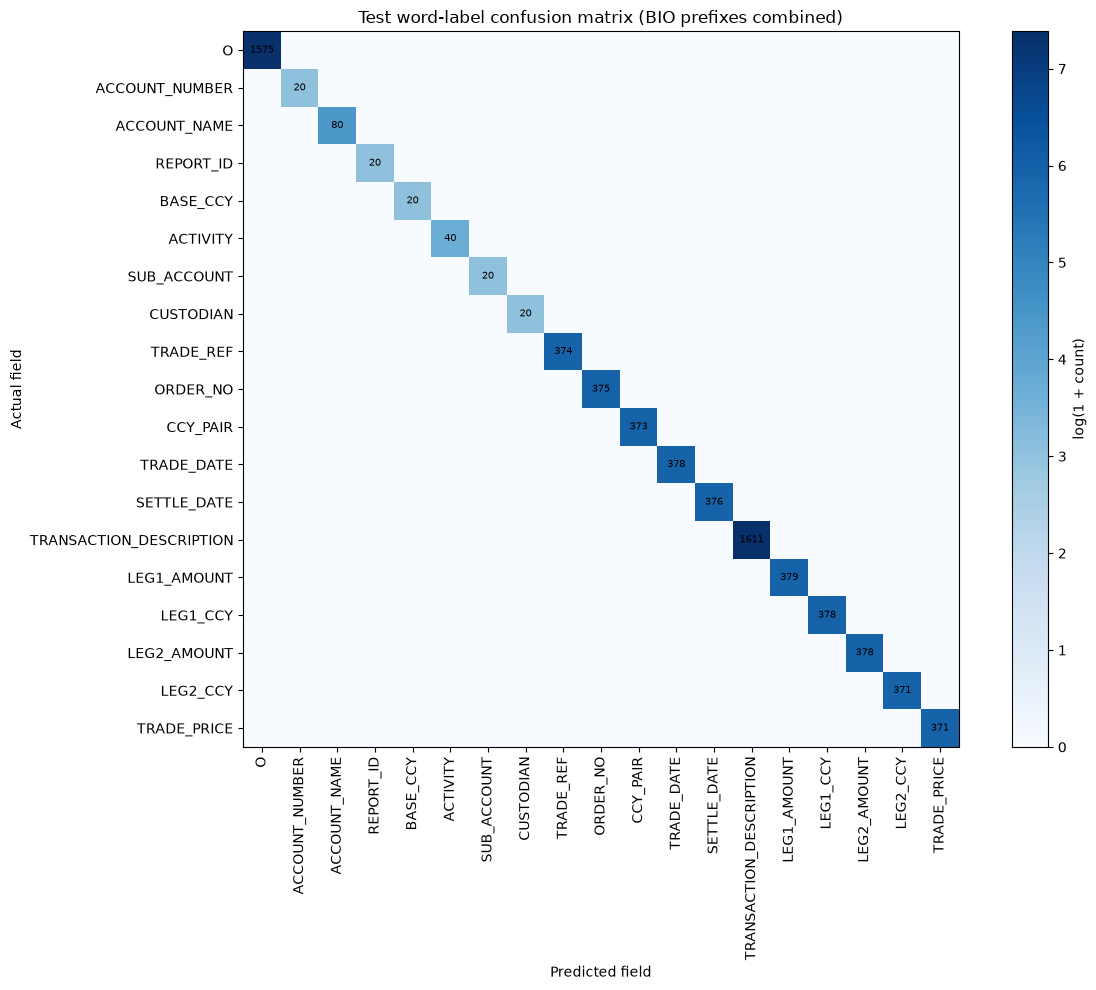

Full BIO confusion counts:


Predicted,O,B-ACCOUNT_NUMBER,I-ACCOUNT_NUMBER,B-ACCOUNT_NAME,I-ACCOUNT_NAME,B-REPORT_ID,I-REPORT_ID,B-BASE_CCY,I-BASE_CCY,B-ACTIVITY,...,B-LEG1_AMOUNT,I-LEG1_AMOUNT,B-LEG1_CCY,I-LEG1_CCY,B-LEG2_AMOUNT,I-LEG2_AMOUNT,B-LEG2_CCY,I-LEG2_CCY,B-TRADE_PRICE,I-TRADE_PRICE
Actual,,,,,,,,,,,,,,,,,,,,,
O,1575,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
B-ACCOUNT_NUMBER,0,20,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
I-ACCOUNT_NUMBER,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
B-ACCOUNT_NAME,0,0,0,20,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
I-ACCOUNT_NAME,0,0,0,0,60,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
B-REPORT_ID,0,0,0,0,0,20,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
I-REPORT_ID,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
B-BASE_CCY,0,0,0,0,0,0,0,20,0,0,...,0,0,0,0,0,0,0,0,0,0
I-BASE_CCY,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


,precision,recall,f1-score,support
O,1.0,1.0,1.0,1575.0
ACCOUNT_NUMBER,1.0,1.0,1.0,20.0
ACCOUNT_NAME,1.0,1.0,1.0,80.0
REPORT_ID,1.0,1.0,1.0,20.0
BASE_CCY,1.0,1.0,1.0,20.0
ACTIVITY,1.0,1.0,1.0,40.0
SUB_ACCOUNT,1.0,1.0,1.0,20.0
CUSTODIAN,1.0,1.0,1.0,20.0
TRADE_REF,1.0,1.0,1.0,374.0
ORDER_NO,1.0,1.0,1.0,375.0


Field-label accuracy: 1.0
Counts include repeated positions from overlapping test windows.


In [16]:
field_confusion = None
bio_confusion = None
if test_output is not None:
    field_confusion = confusion_table(test_output.predictions, test_output.label_ids, collapse_bio=True)
    bio_confusion = confusion_table(test_output.predictions, test_output.label_ids, collapse_bio=False)
    display(metric_summary(test_output.metrics, "test"))
    display(field_confusion)
    plot_confusion(field_confusion)
    print("Full BIO confusion counts:")
    display(bio_confusion)
    keep = test_output.label_ids != -100
    guessed_ids = np.argmax(test_output.predictions, axis=-1)[keep]
    actual_ids = test_output.label_ids[keep]
    actual_fields = [field_name(id2label[int(value)]) or "O" for value in actual_ids]
    guessed_fields = [field_name(id2label[int(value)]) or "O" for value in guessed_ids]
    classification = word_classification_report(actual_fields, guessed_fields,
        labels=["O"]+FIELDS, output_dict=True, zero_division=0)
    report_rows = {key:value for key,value in classification.items() if isinstance(value,dict)}
    display(pd.DataFrame(report_rows).T)
    print("Field-label accuracy:", accuracy_score(actual_fields, guessed_fields))
    print("Counts include repeated positions from overlapping test windows.")
else:
    print("No model confusion matrix yet. Run model testing in Section 16 first.")

## Section 18 — Save the Trained Financial Model to Google Drive

Save model weights/configuration, processor, extraction settings and run metrics to `/content/drive/MyDrive/personal/model-output`. This folder persists after a Colab runtime reset. Keep the complete folder for inference.


In [17]:
if trainer is not None and trainer.state.global_step > 0:
    trainer.save_model(OUTPUT_DIR)
    processor.save_pretrained(OUTPUT_DIR)

    extraction_config = {
        "schema_version": 1,
        "layout": SUPPORTED_LAYOUT,
        "supported_document": "Morgan Stanley FX Forward",
        "fields": FIELDS,
        "meta_fields": META_FIELDS,
        "row_fields": ROW_FIELDS,
        "labels": LABELS,
        "max_length": MAX_LENGTH,
        "stride": STRIDE,
        "base_model": MODEL_NAME,
    }

    Path(OUTPUT_DIR, "extraction_config.json").write_text(
        json.dumps(extraction_config, indent=2),
        encoding="utf-8",
    )

    run_metrics = {
        "epochs": EPOCHS,
        "selected_pdf_counts": {split: len(paths) for split, paths in PDFS_BY_SPLIT.items()},
        "reference_labels": "rule-assisted unless human-reviewed" if USE_UNREVIEWED_RULE_LABELS else "human-reviewed",
        "training_history": trainer.state.log_history,
        "validation": validation_metrics,
        "test": test_output.metrics if test_output is not None else None,
    }
    Path(OUTPUT_DIR, "run_metrics.json").write_text(
        json.dumps(run_metrics, indent=2), encoding="utf-8"
    )

    print("Saved trained financial model + processor:", OUTPUT_DIR)
    print(
        "Copy/download the ENTIRE model folder. "
        "It is portable between Colab and local CPU/GPU environments."
    )
else:
    print("No trained model to save.")


Saved trained financial model + processor: /content/drive/MyDrive/personal/model-output
Copy/download the ENTIRE model folder. It is portable between Colab and local CPU/GPU environments.


## Section 19 — Reload Saved Morgan Stanley FX Forward Model and Run PDF → JSON

The saved model predicts token labels; this helper packages PyMuPDF extraction, the same normalized boxes/page image, Morgan Stanley FX Forward row grouping, and JSON post-processing into `predict_pdf_to_json(pdf_path, model_dir)`.

**Scope:** use this only for the supported Morgan Stanley FX Forward report layout. The notebook intentionally rejects different counterparties, activities, and materially different layouts.


In [18]:
def load_saved_trade_model(model_dir):
    model_dir = Path(model_dir)
    assert (model_dir / "config.json").exists(), (
        f"No saved model found in {model_dir}"
    )

    config_path = model_dir / "extraction_config.json"
    runtime_config = (
        json.loads(config_path.read_text(encoding="utf-8"))
        if config_path.exists()
        else {}
    )

    saved_layout = runtime_config.get("layout")
    if saved_layout is not None:
        assert saved_layout == SUPPORTED_LAYOUT, (
            f"Wrong model for this notebook: {saved_layout}. "
            f"Expected {SUPPORTED_LAYOUT}."
        )

    inference_processor = AutoProcessor.from_pretrained(
        model_dir,
        apply_ocr=False,
    )
    inference_model = AutoModelForTokenClassification.from_pretrained(
        model_dir
    )

    expected_labels = runtime_config.get("labels", LABELS)
    expected_label2id = {
        label: index
        for index, label in enumerate(expected_labels)
    }

    assert inference_model.config.label2id == expected_label2id, (
        "The saved model label vocabulary does not match this extractor."
    )

    device = torch.device(
        "cuda" if torch.cuda.is_available() else "cpu"
    )
    inference_model.to(device).eval()

    return inference_processor, inference_model, runtime_config


def predict_page(
    record,
    inference_model,
    inference_processor,
    max_length=MAX_LENGTH,
    stride=STRIDE,
):
    inputs = inference_processor(
        render_page(record),
        record["words"],
        boxes=record["bboxes"],
        truncation=True,
        padding="max_length",
        max_length=max_length,
        return_overflowing_tokens=True,
        stride=stride,
        return_offsets_mapping=True,
        return_tensors="pt",
    )

    if isinstance(inputs["pixel_values"], list):
        inputs["pixel_values"] = torch.stack(inputs["pixel_values"])

    selected = {}

    for window in range(inputs["input_ids"].shape[0]):
        model_inputs = {
            key: value[window:window + 1].to(inference_model.device)
            for key, value in inputs.items()
            if key not in {
                "offset_mapping",
                "overflow_to_sample_mapping",
            }
        }

        with torch.inference_mode():
            probabilities = (
                inference_model(**model_inputs)
                .logits[0]
                .softmax(-1)
                .cpu()
            )

        for position, word_id in enumerate(inputs.word_ids(window)):
            if word_id is None:
                continue

            # Keep only the first subword of each original PDF word.
            if int(inputs["offset_mapping"][window, position, 0]) != 0:
                continue

            score, predicted_id = probabilities[position].max(-1)
            score = float(score)
            label = inference_model.config.id2label[
                int(predicted_id)
            ]

            if (
                word_id not in selected
                or score > selected[word_id][1]
            ):
                selected[word_id] = (label, score)

    assert len(selected) == len(record["words"]), (
        "Incomplete word coverage during inference."
    )

    labels = [
        selected[index][0]
        for index in range(len(record["words"]))
    ]
    scores = [
        selected[index][1]
        for index in range(len(record["words"]))
    ]

    return labels, scores


def _combine_page_json(page_results, pdf_path):
    metadata = {}

    for field in META_FIELDS:
        key = field.lower()
        values = [
            page["metadata"].get(key)
            for page in page_results
            if page["metadata"].get(key)
        ]
        metadata[key] = values[0] if values else None

    transactions = [
        transaction
        for page in page_results
        for transaction in page["transactions"]
    ]

    return {
        "source_pdf": str(Path(pdf_path).resolve()),
        "document_id": (
            page_results[0]["document_id"]
            if page_results
            else None
        ),
        "metadata": metadata,
        "transactions": transactions,
    }


def predict_pdf_to_json(
    pdf_path,
    model_dir=OUTPUT_DIR,
    output_json_path=None,
):
    """
    End-to-end inference for a new Morgan Stanley FX Forward PDF.

    PDF
      -> PyMuPDF words + boxes + page image
      -> saved LayoutLMv3 token classifier
      -> row-aware entity grouping
      -> normalized transaction JSON
    """
    pdf_path = Path(pdf_path)
    assert pdf_path.is_file(), f"PDF not found: {pdf_path}"
    assert_supported_pdf(pdf_path)

    (
        inference_processor,
        inference_model,
        runtime_config,
    ) = load_saved_trade_model(model_dir)

    max_length = int(
        runtime_config.get("max_length", MAX_LENGTH)
    )
    stride = int(
        runtime_config.get("stride", STRIDE)
    )

    page_results = []

    for raw_record in extract_pdf(pdf_path):
        # This stage supplies transaction row IDs / row bands only.
        # Model predictions below replace the rule-draft BIO labels.
        geometry = suggest_annotations(raw_record)

        assert not geometry["issues"], (
            "This PDF does not match the currently supported "
            f"Morgan Stanley table geometry: {geometry['issues']}"
        )
        assert geometry["row_bands"], (
            "No transaction rows detected. "
            "Add/adjust a grouping adapter for this layout."
        )

        labels, scores = predict_page(
            geometry,
            inference_model,
            inference_processor,
            max_length=max_length,
            stride=stride,
        )

        page_json = transaction_json(
            geometry,
            labels=labels,
            confidences=scores,
            source="trained_layoutlmv3",
        )
        page_results.append(page_json)

    result = _combine_page_json(page_results, pdf_path)

    if output_json_path is not None:
        output_json_path = Path(output_json_path)
        output_json_path.parent.mkdir(
            parents=True,
            exist_ok=True,
        )
        output_json_path.write_text(
            json.dumps(result, indent=2),
            encoding="utf-8",
        )
        print("Saved JSON:", output_json_path.resolve())

    return result


# Example AFTER Section 18 has saved the trained model:
#
# new_pdf = "/content/drive/MyDrive/personal/new_pdfs/example.pdf"
# result = predict_pdf_to_json(
#     new_pdf,
#     model_dir=OUTPUT_DIR,
#     output_json_path="/content/drive/MyDrive/personal/model-output/example.json",
# )
# print(json.dumps(result, indent=2))

if RUN_MODEL_INFERENCE:
    input_pdf = PDFS_BY_SPLIT["test"][0]
    model_predictions = predict_pdf_to_json(
        input_pdf,
        model_dir=OUTPUT_DIR,
    )
    print(json.dumps(model_predictions, indent=2))
else:
    print(
        "Inference example is off. Set RUN_MODEL_INFERENCE=True "
        "or call predict_pdf_to_json(...) after saving the model."
    )


Inference example is off. Set RUN_MODEL_INFERENCE=True or call predict_pdf_to_json(...) after saving the model.


## Section 20 — Interpret Results and Improve This Morgan Stanley FX Forward Model

Evaluate this model only against held-out Morgan Stanley FX Forward PDFs using the supported layout. Review validation/test labels before treating metrics as business accuracy.

Keep CANCEL rows and raw amounts. Netting, posting and downstream business cancellation semantics remain outside this extraction POC.


In [19]:
print("Dataset folder:", DATASET_DIR)
print("Model folder:", OUTPUT_DIR)
print(
    "Folder PDF counts selected:",
    {split: len(paths) for split, paths in PDFS_BY_SPLIT.items()},
)
print(
    "Training: Section 14 | Validation: Section 15 | "
    "Testing: Section 16 | Confusion matrix: Section 17"
)
print(
    "Saved-model inference: "
    "predict_pdf_to_json('/path/new.pdf', model_dir=OUTPUT_DIR)"
)
print(
    "Scope: Morgan Stanley FX Forward only. For real accuracy claims, "
    "independently review the validation/test labels."
)


Dataset folder: /content/drive/MyDrive/personal/dataset
Model folder: /content/drive/MyDrive/personal/model-output
Folder PDF counts selected: {'train': 100, 'validation': 20, 'test': 20}
Training: Section 14 | Validation: Section 15 | Testing: Section 16 | Confusion matrix: Section 17
Saved-model inference: predict_pdf_to_json('/path/new.pdf', model_dir=OUTPUT_DIR)
Scope: Morgan Stanley FX Forward only. For real accuracy claims, independently review the validation/test labels.
